In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

from trainer.src.train import train_model
from trainer.src.features import add_feature_failure_target
# from trainer.src.influx_reader import load_data

# Load data

In [4]:
# df = load_data()

In [19]:
df = pd.read_csv("../datasets/sensors.csv", index_col=0)

# EDA

## Dataset overview

In [162]:
df.shape

(11561, 11)

In [130]:
df.head()

,time,device_id,current,failure,humidity,load,pressure,rpm,temperature,vibration,wear
0,2026-08-15T12:40:02.862800+00:00,motor_000,14.58,0,43.7,0.542,6.01,2146.0,59.64,0.55,0.0001
1,2026-08-15T12:40:04.188077+00:00,motor_000,14.71,0,39.0,0.543,6.04,2142.0,58.45,0.66,0.0003
2,2026-08-15T12:40:05.202272+00:00,motor_000,15.09,0,47.6,0.553,5.99,2190.0,58.83,0.57,0.0004
3,2026-08-15T12:40:06.220667+00:00,motor_000,15.05,0,45.9,0.534,6.12,2122.0,57.48,0.57,0.0005
4,2026-08-15T12:40:07.225393+00:00,motor_000,14.42,0,46.0,0.539,5.97,2128.0,57.00,0.54,0.0007


In [131]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32231 entries, 0 to 32230
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   time         32231 non-null  str    
 1   device_id    32231 non-null  str    
 2   current      32231 non-null  float64
 3   failure      32231 non-null  int64  
 4   humidity     32231 non-null  float64
 5   load         32231 non-null  float64
 6   pressure     32231 non-null  float64
 7   rpm          32231 non-null  float64
 8   temperature  32231 non-null  float64
 9   vibration    32231 non-null  float64
 10  wear         32231 non-null  float64
dtypes: float64(8), int64(1), str(2)
memory usage: 2.7 MB


In [132]:
df.describe()

,current,failure,humidity,load,pressure,rpm,temperature,vibration,wear
count,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000,32231.000000
mean,16.417646,0.003568,44.979020,0.625936,5.947786,2243.967764,62.716237,0.652377,0.025492
std,4.161495,0.059627,3.992324,0.223690,0.243407,293.755447,8.451868,0.343840,0.020451
min,1.230000,0.000000,28.900000,0.200000,1.580000,114.000000,45.160000,0.270000,0.000100
25%,13.140000,0.000000,42.300000,0.445000,5.920000,2031.000000,56.120000,0.540000,0.009800
50%,16.730000,0.000000,45.000000,0.641000,5.960000,2268.000000,63.170000,0.640000,0.020600
75%,19.860000,0.000000,47.700000,0.813000,6.000000,2475.000000,69.260000,0.730000,0.037000
max,24.460000,1.000000,62.400000,1.000000,6.190000,2760.000000,115.540000,6.910000,0.130800


In [133]:
df["device_id"].nunique()

4

In [134]:
df["device_id"].value_counts()

device_id
motor_000    8256
motor_001    8113
motor_002    7974
motor_003    7888
Name: count, dtype: int64

In [135]:
df.groupby("device_id")["time"].agg(["min", "max", "count"])

,min,max,count
device_id,,,
motor_000,2026-08-15T12:40:02.862800+00:00,2026-08-15T14:59:25.099670+00:00,8256
motor_001,2026-08-15T12:40:02.965338+00:00,2026-08-15T14:59:25.096368+00:00,8113
motor_002,2026-08-15T12:40:02.870936+00:00,2026-08-15T14:59:25.097895+00:00,7974
motor_003,2026-08-15T12:40:02.872278+00:00,2026-08-15T14:59:25.097922+00:00,7888


## Temporal structure

In [136]:
dft = df.copy()
dft["time"] = pd.to_datetime(dft["time"])
dft = dft.sort_values(["device_id", "time"])

In [137]:
time_range = (
    dft.groupby("device_id")["time"]
    .agg(
        start="min",
        end="max",
        observations="count"
    )
)

time_range["duration"] = time_range["end"] - time_range["start"]

In [138]:
time_range

,start,end,observations,duration
device_id,,,,
motor_000,2026-08-15 12:40:02.862800+00:00,2026-08-15 14:59:25.099670+00:00,8256,0 days 02:19:22.236870
motor_001,2026-08-15 12:40:02.965338+00:00,2026-08-15 14:59:25.096368+00:00,8113,0 days 02:19:22.131030
motor_002,2026-08-15 12:40:02.870936+00:00,2026-08-15 14:59:25.097895+00:00,7974,0 days 02:19:22.226959
motor_003,2026-08-15 12:40:02.872278+00:00,2026-08-15 14:59:25.097922+00:00,7888,0 days 02:19:22.225644


In [139]:
dft["dt"] = (
    dft.groupby("device_id")["time"]
    .diff()
    .dt.total_seconds()
)

sampling_stats = (
    dft.groupby("device_id")["dt"]
    .agg(
        mean="mean",
        median="median",
        std="std",
        max="max",
        min="min",
    )
)

In [140]:
sampling_stats.head()

,mean,median,std,max,min
device_id,,,,,
motor_000,1.012991,1.014792,0.006296,1.325277,1.000820
motor_001,1.030835,1.014848,0.138371,3.053324,1.000041
motor_002,1.048818,1.015154,0.199290,4.050325,1.000707
motor_003,1.060254,1.015200,0.226523,3.061731,1.000097


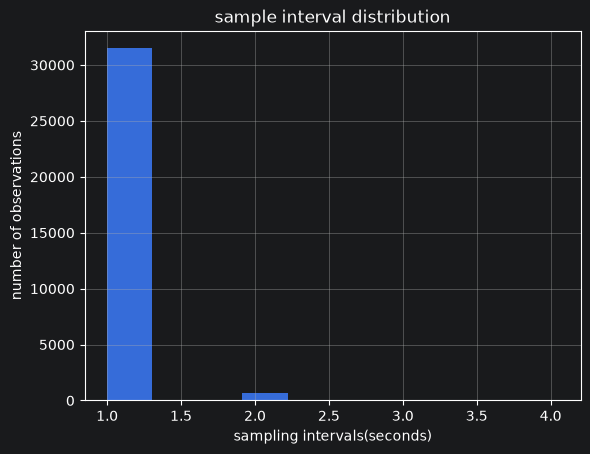

In [141]:
dft["dt"].dropna().hist()
plt.ylabel("number of observations")
plt.xlabel("sampling intervals(seconds)")
plt.title("sample interval distribution")
plt.show()

In [142]:
expected = 1
thresh = expected * 2

gaps = dft[(dft["dt"] > thresh) & dft["dt"].notna()]

In [143]:
gaps[["device_id", "time", "dt"]]

,device_id,time,dt
8797,motor_001,2026-08-15 12:49:11.539673+00:00,2.020968
8807,motor_001,2026-08-15 12:49:22.636262+00:00,2.023361
8858,motor_001,2026-08-15 12:50:15.207833+00:00,2.024216
8862,motor_001,2026-08-15 12:50:20.274241+00:00,2.025693
8878,motor_001,2026-08-15 12:50:37.472843+00:00,2.026349
...,...,...,...
32177,motor_003,2026-08-15 14:58:27.278315+00:00,2.024215
32186,motor_003,2026-08-15 14:58:37.419628+00:00,2.023249
32194,motor_003,2026-08-15 14:58:46.550601+00:00,2.026629
32215,motor_003,2026-08-15 14:59:08.859962+00:00,2.038386


In [144]:
gaps_by_device = gaps.groupby("device_id").size()
gaps_by_device

device_id
motor_001    138
motor_002    265
motor_003    347
dtype: int64

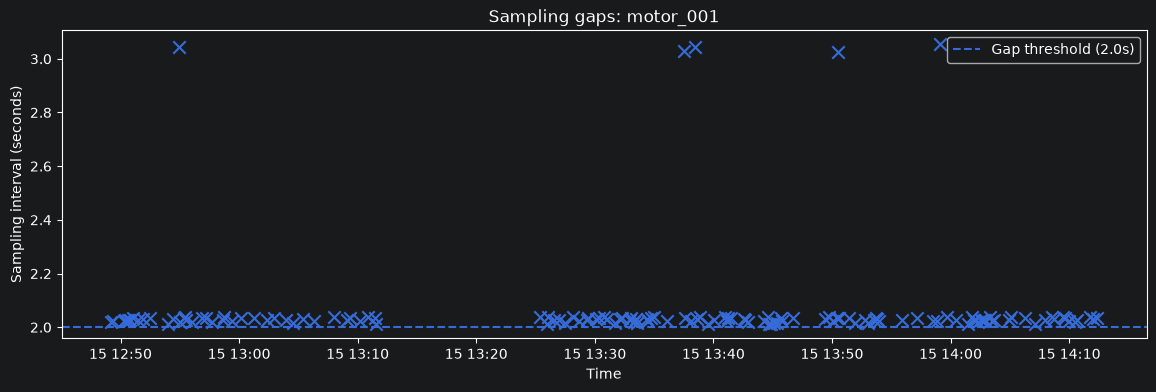

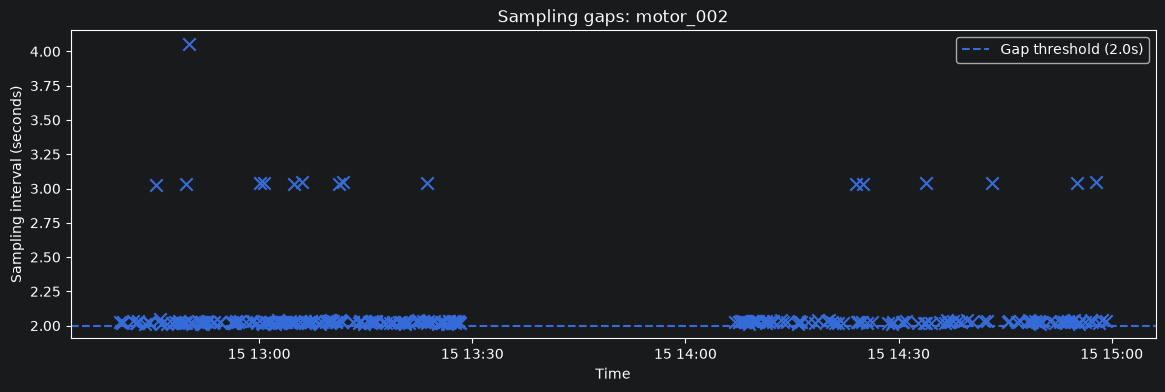

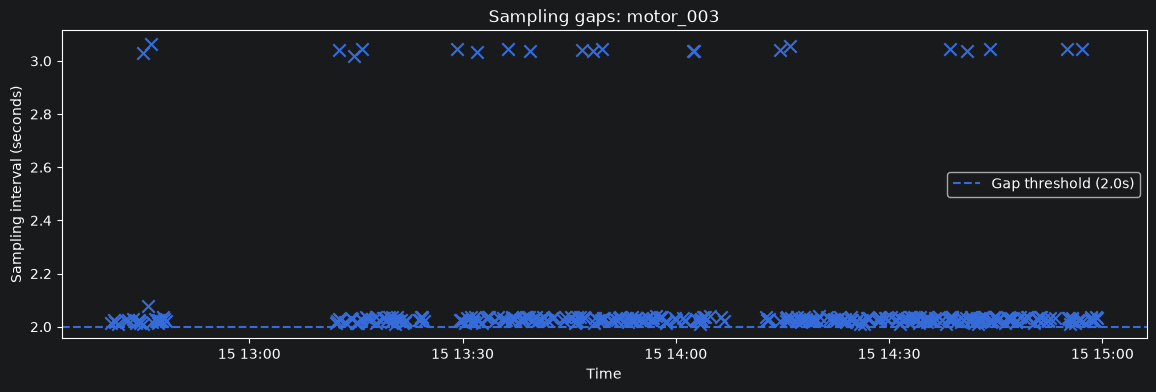

In [145]:
for device_id, device_gaps in gaps.groupby("device_id"):
    plt.figure(figsize=(14, 4))

    plt.scatter(
        device_gaps["time"],
        device_gaps["dt"],
        marker="x",
        s=80,
        zorder=2,
    )

    plt.axhline(
        thresh,
        linestyle="--",
        label=f"Gap threshold ({thresh:.1f}s)",
    )

    plt.title(f"Sampling gaps: {device_id}")
    plt.xlabel("Time")
    plt.ylabel("Sampling interval (seconds)")
    plt.legend()
    plt.show()

## Features distribution

In [146]:
features = df.columns.drop('time').drop('device_id')
features

Index(['current', 'failure', 'humidity', 'load', 'pressure', 'rpm',
       'temperature', 'vibration', 'wear'],
      dtype='str')

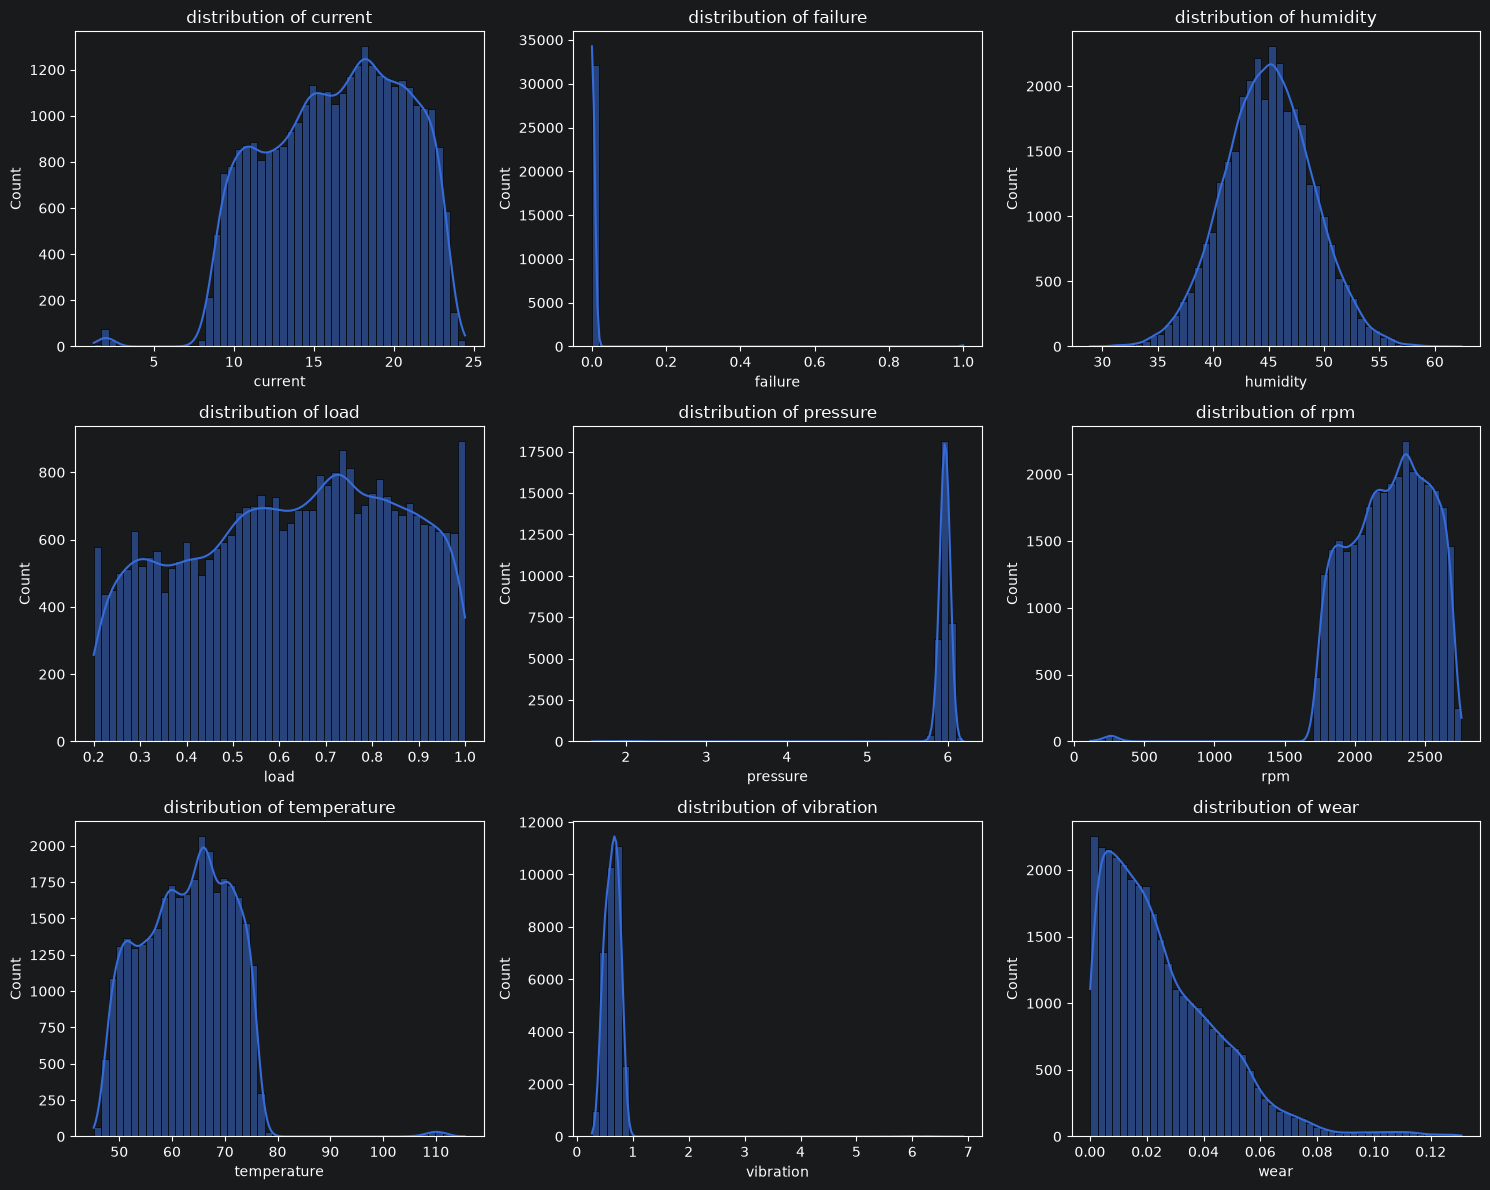

In [147]:
n_features = len(features)

fig, axes = plt.subplots(
    nrows=(n_features + 2) // 3,
    ncols=3,
    figsize=(15, 12)
)

axes = axes.flatten()

for ax, feature in zip(axes, features, strict=False):
    sns.histplot(
        data=df,
        x=feature,
        bins=50,
        kde=True,
        ax=ax
    )

    ax.set_title(f"distribution of {feature}")
    ax.set_xlabel(feature)

# remove unused axes
for ax in axes[n_features:]:
    ax.remove()

plt.tight_layout()
plt.show()

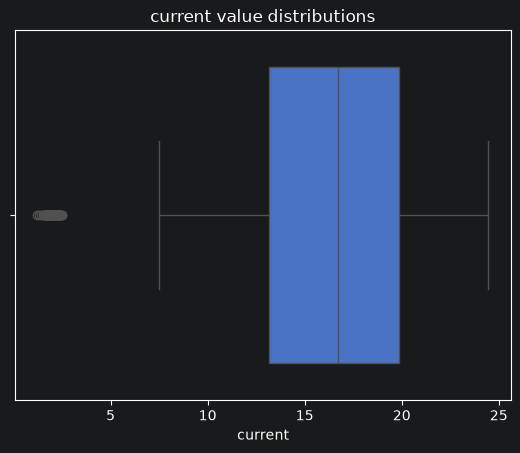

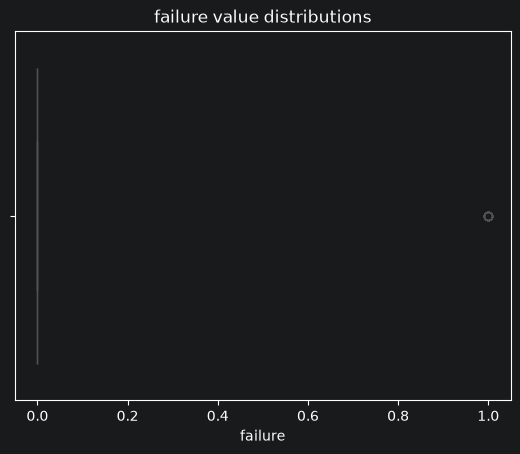

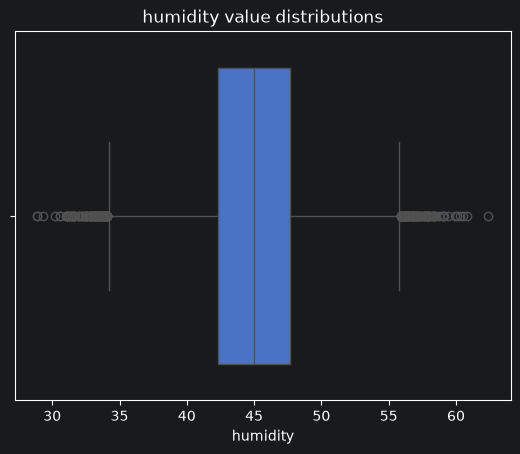

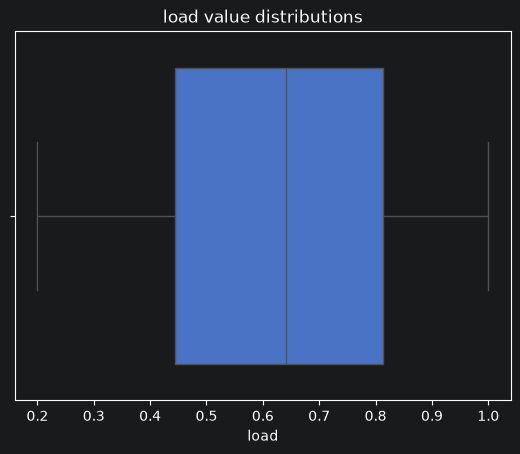

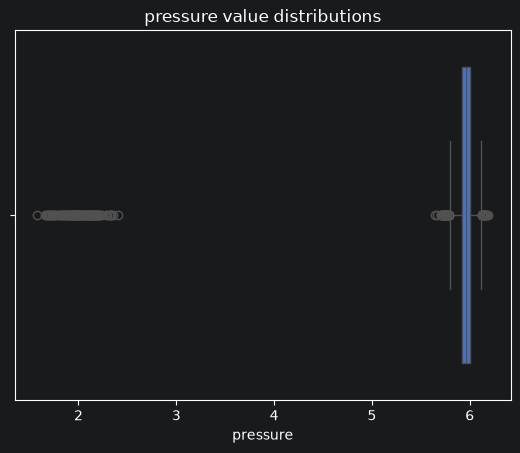

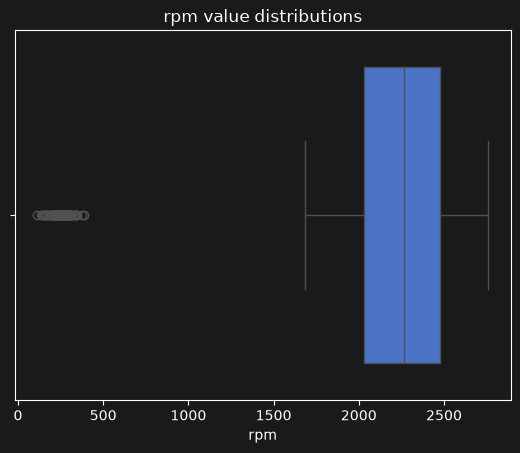

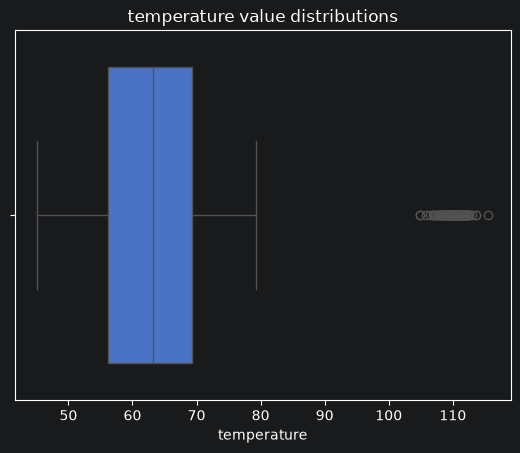

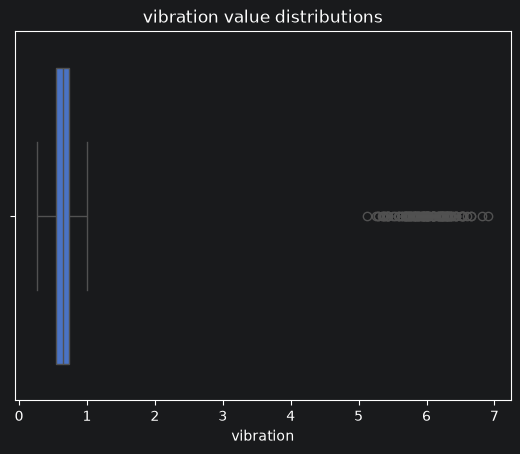

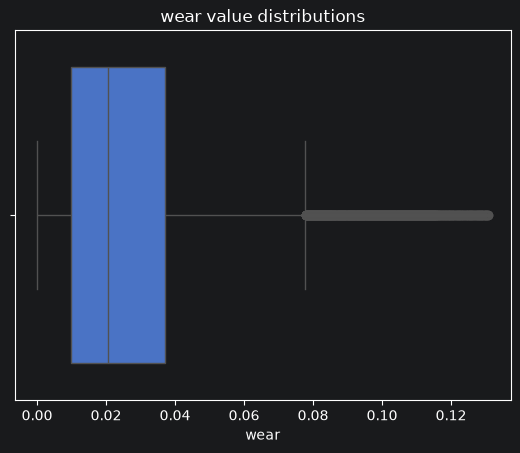

In [148]:
for feature in features:
    sns.boxplot(
        data=df,
        x=feature
    )

    plt.title(f"{feature} value distributions")
    plt.show()

## Correlation

In [149]:
corr = df[features].corr()

<Axes: >

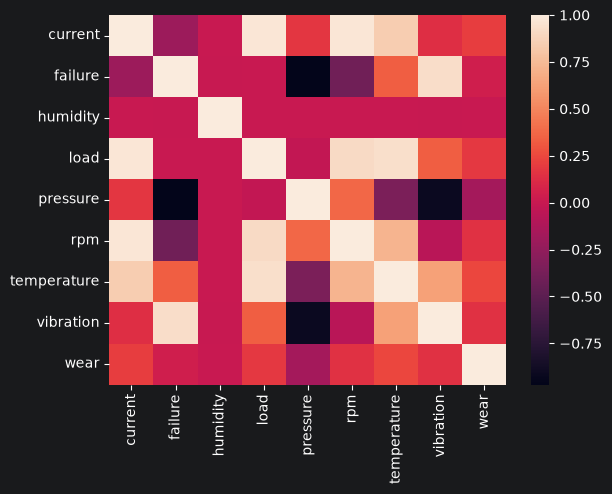

In [150]:
sns.heatmap(corr)

## Sensor dynamics

In [151]:
device = "motor_001"

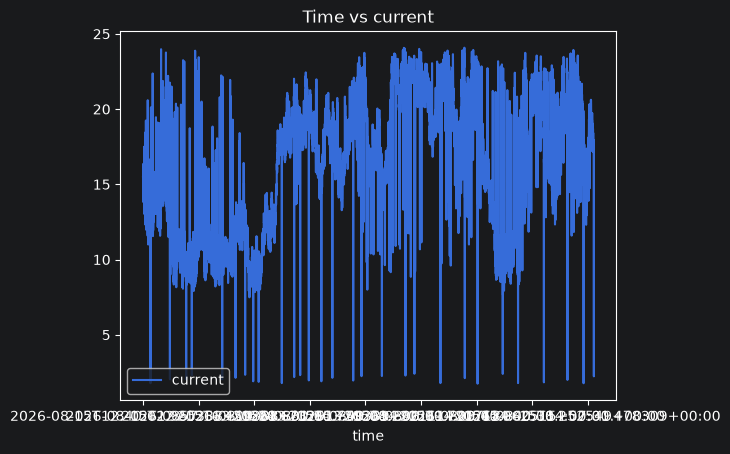

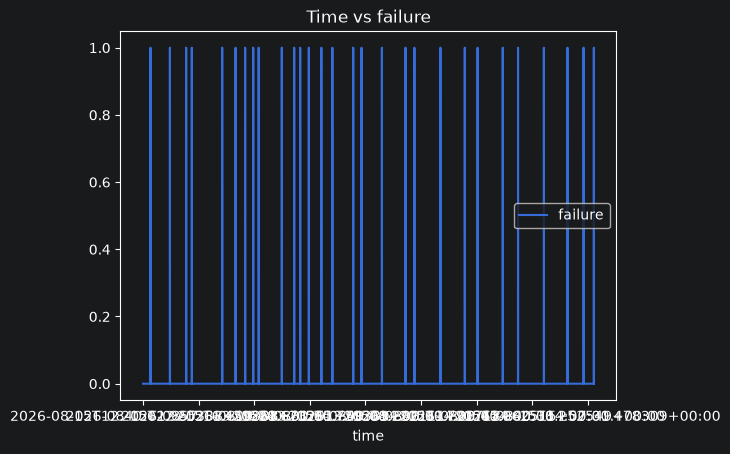

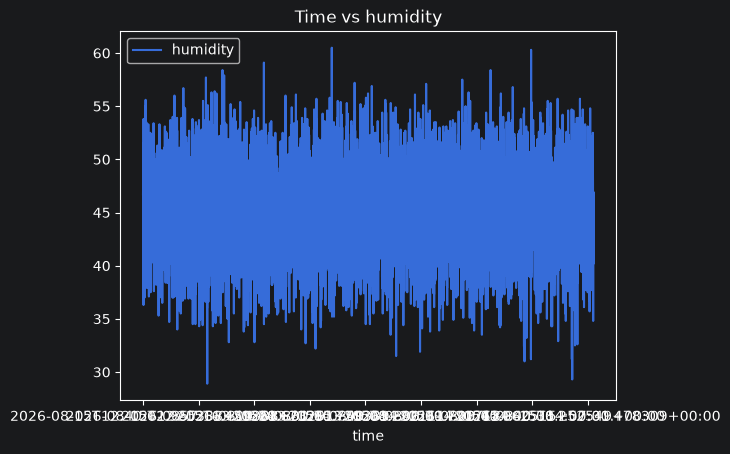

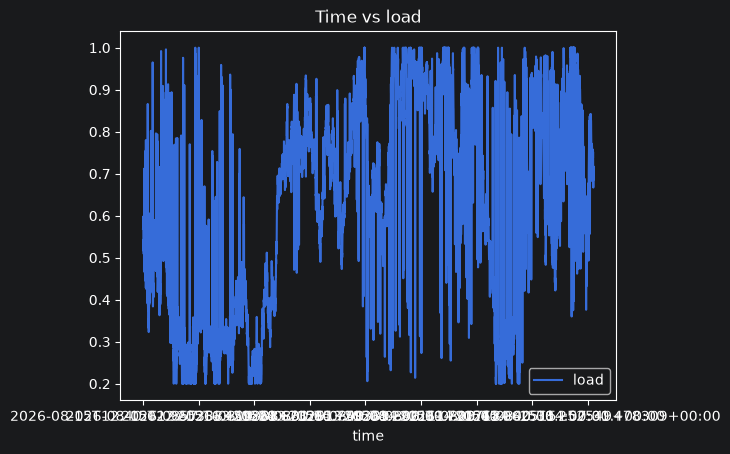

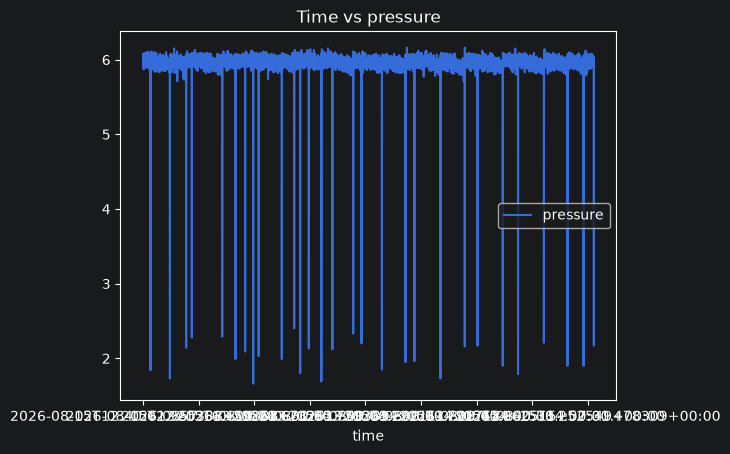

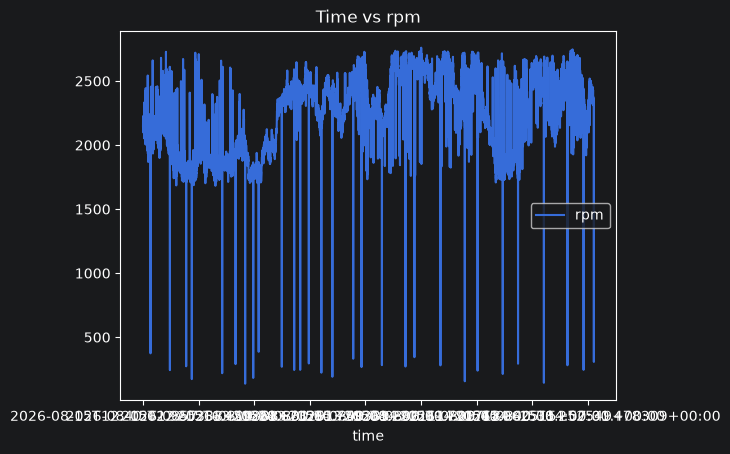

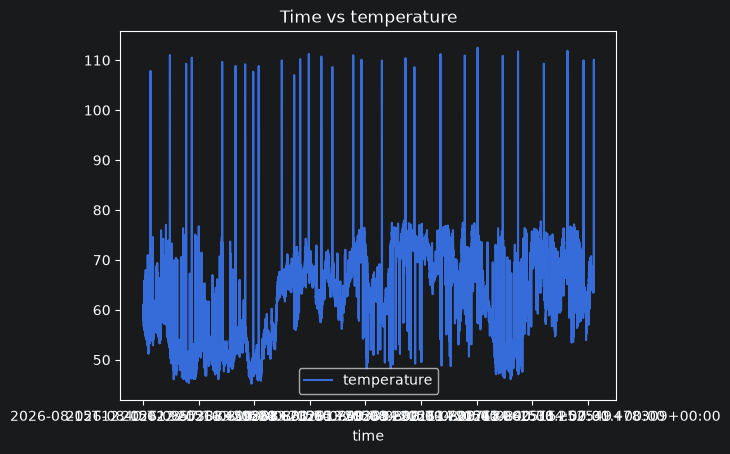

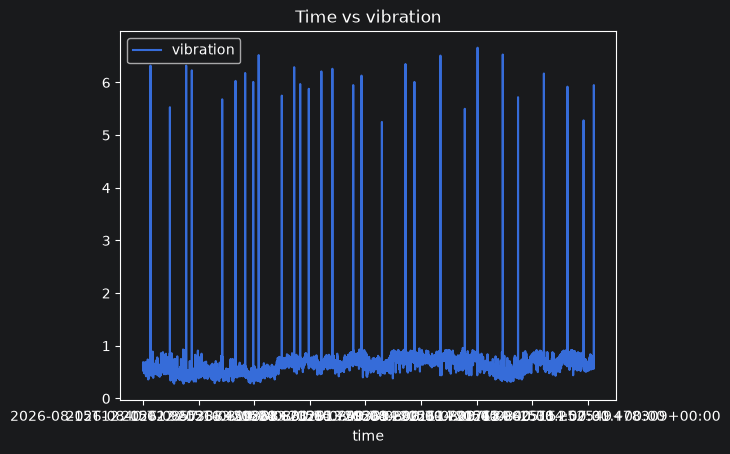

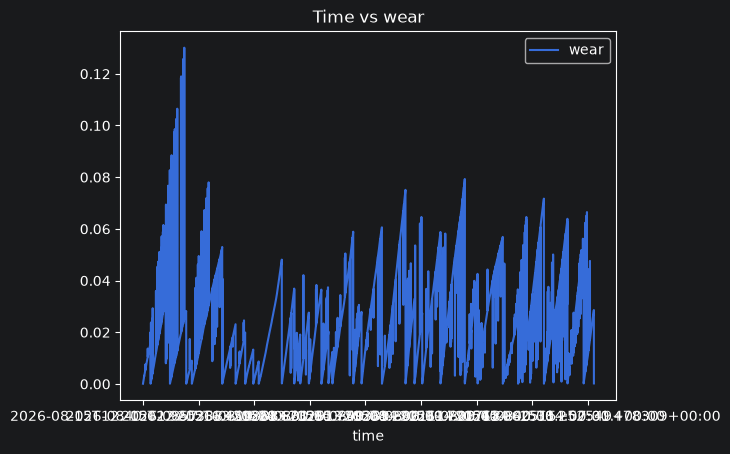

In [152]:
subset = df[df['device_id'] == device].drop(columns='device_id')

for feature in features:
    subset.plot(x='time',
                y=feature,
                title=f"Time vs {feature}")

looks like spikes in some features lead to spikes in failure, lets see

In [153]:
# time as index for faster plots
subset = subset.set_index('time')
subset.index = pd.to_datetime(subset.index)

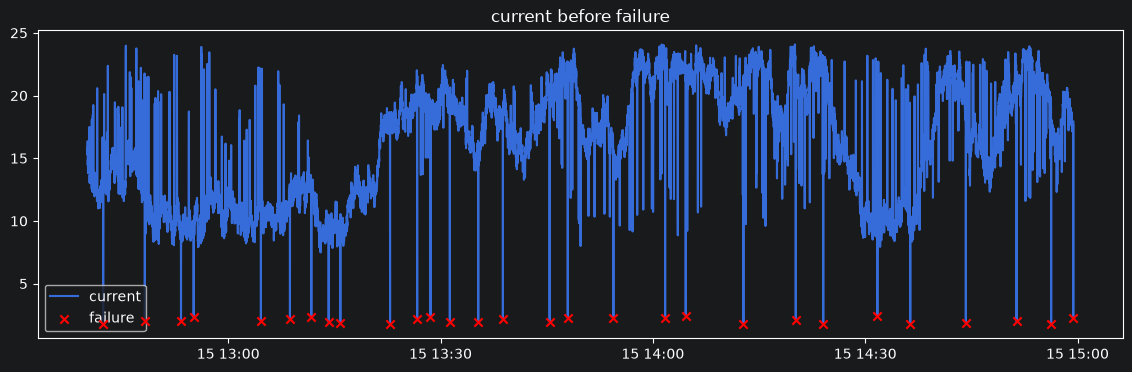

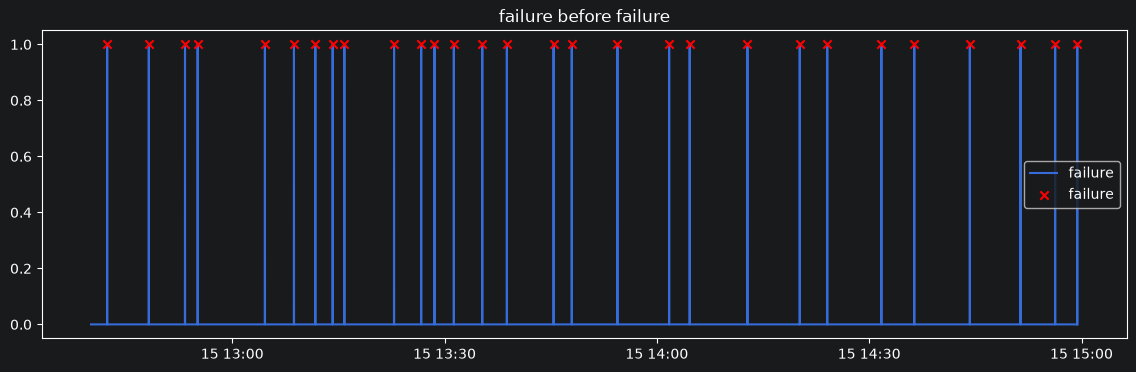

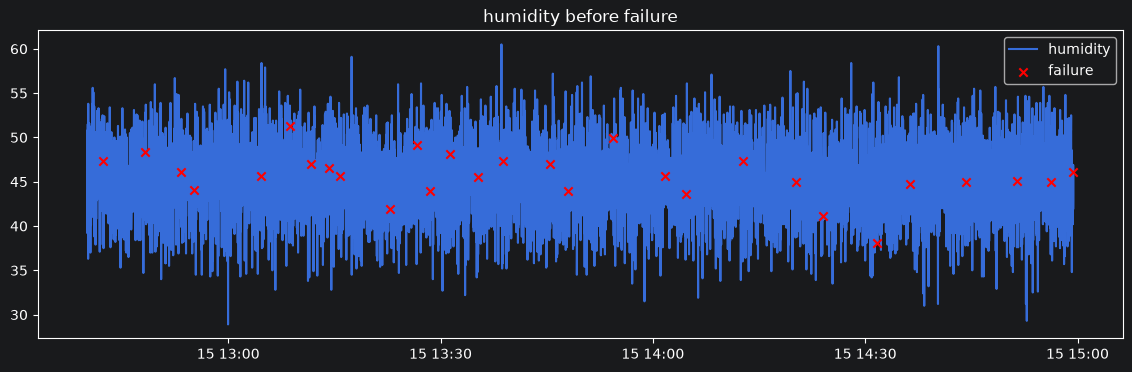

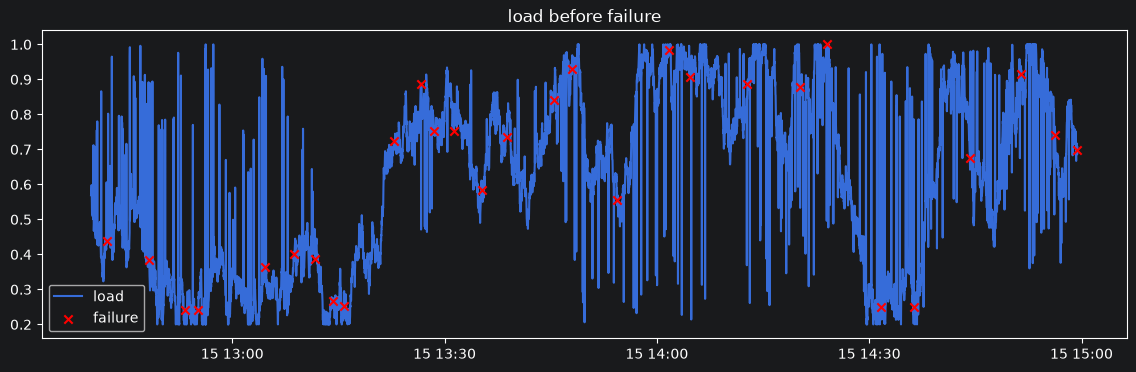

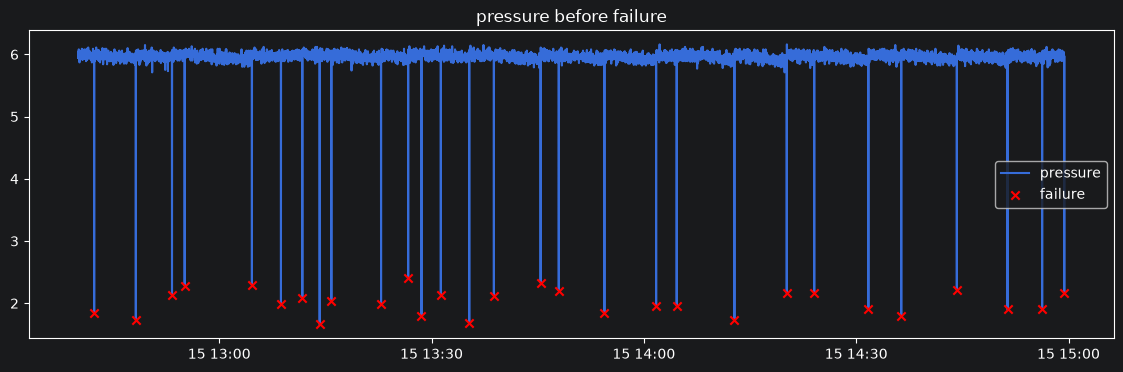

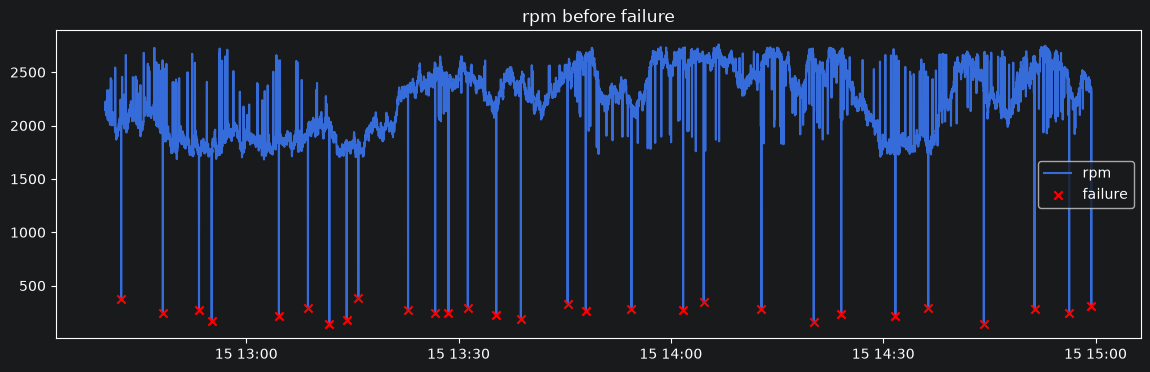

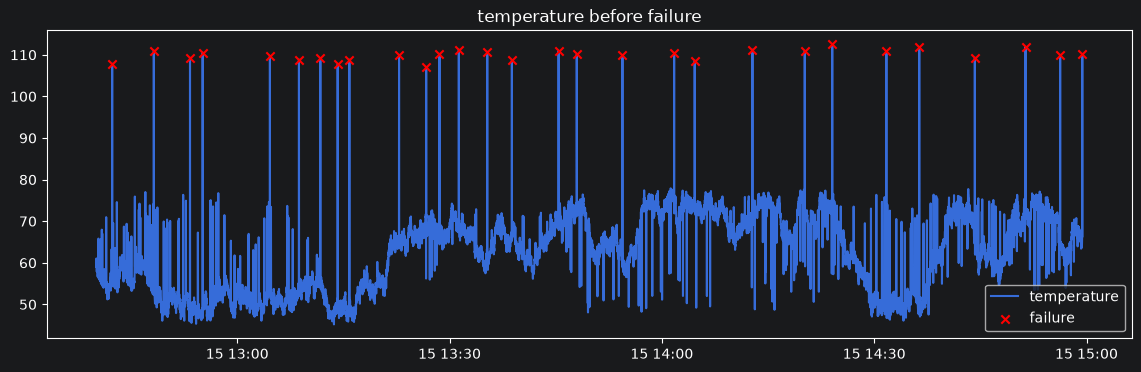

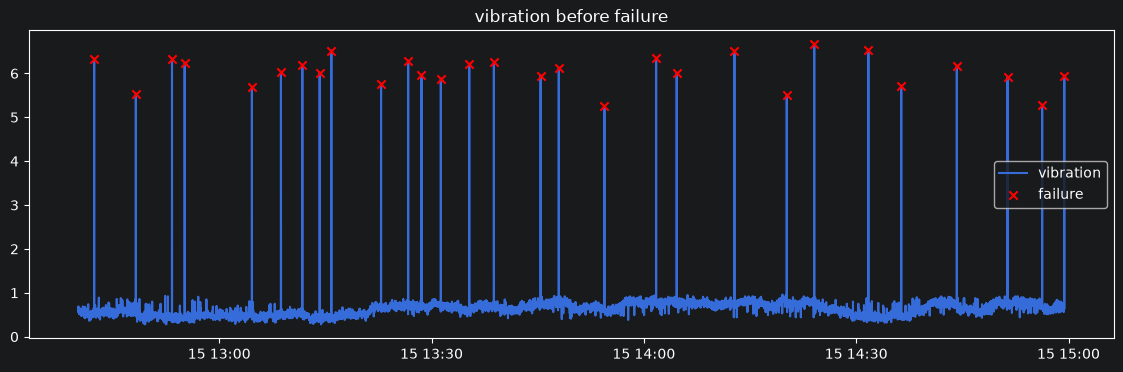

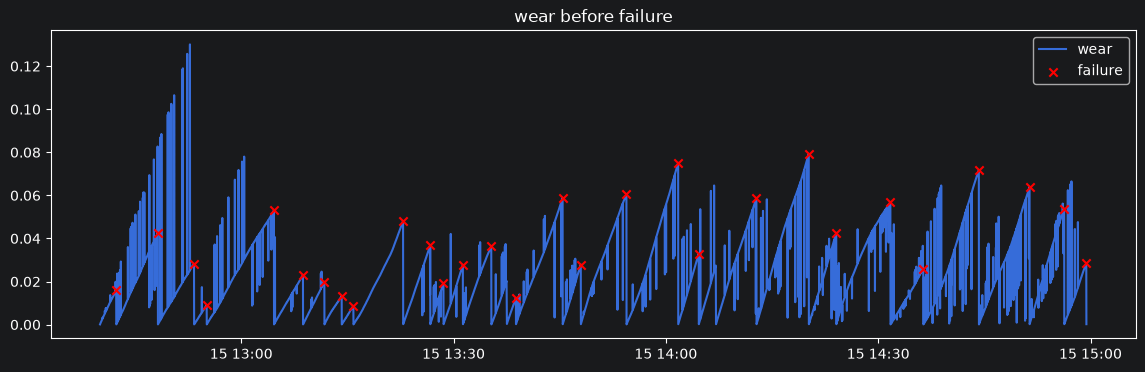

In [154]:
failure_points = subset[subset["failure"] == 1]

for feature in features:
    plt.figure(figsize=(14, 4))

    plt.plot(
        subset.index,
        subset[feature],
        label=feature,
        zorder=1
    )

    plt.scatter(
        failure_points.index,
        failure_points[feature],
        marker='x',
        label='failure',
        color='red',
        zorder=10
    )

    plt.title(f"{feature} before failure")
    plt.legend()
    plt.show()

## Pre-failure behavior

In [155]:
window_seconds = 60

In [156]:
features = features.drop("failure")

In [157]:
dfr = df.copy()
dfr["time"] = pd.to_datetime(dfr["time"])
dfr = dfr.sort_values(["device_id", "time"])

In [158]:
failures = dfr[dfr["failure"] == 1][["device_id", "time"]].rename(columns={"time": "failure_time"})

In [159]:
windows = []

for _, failure in failures.iterrows():
    device_data = dfr[dfr["device_id"] == failure["device_id"]].copy()

    start_time = failure["failure_time"] - pd.Timedelta(
        seconds=window_seconds
    )

    window = device_data[
        (device_data["time"] >= start_time)
        & (device_data["time"] <= failure["failure_time"])
        ].copy()

    window["failure_time"] = failure["failure_time"]
    window["relative_time"] = (
            window["time"] - failure["failure_time"]
    ).dt.total_seconds()

    windows.append(window)

failure_windows = pd.concat(windows, ignore_index=True)

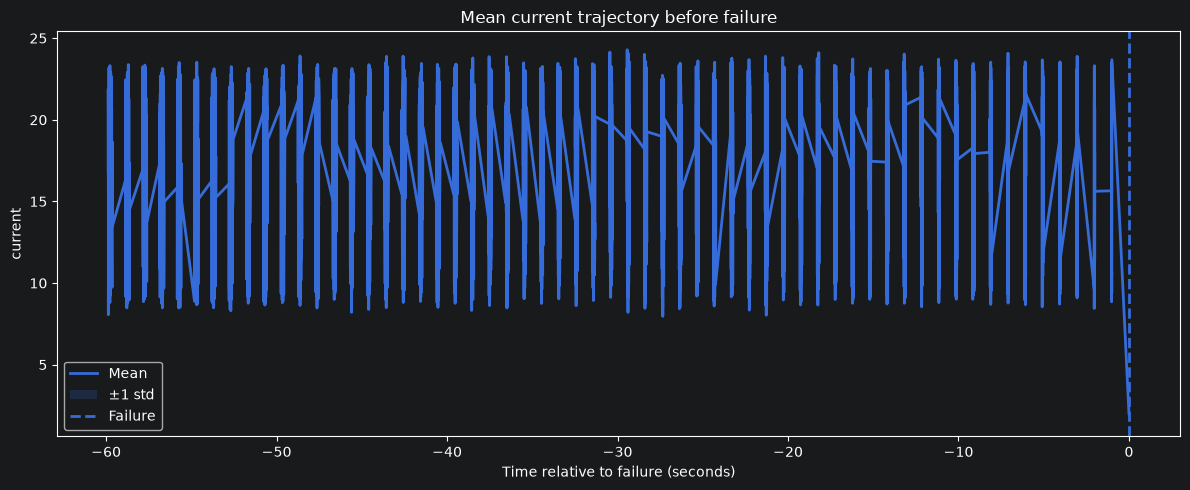

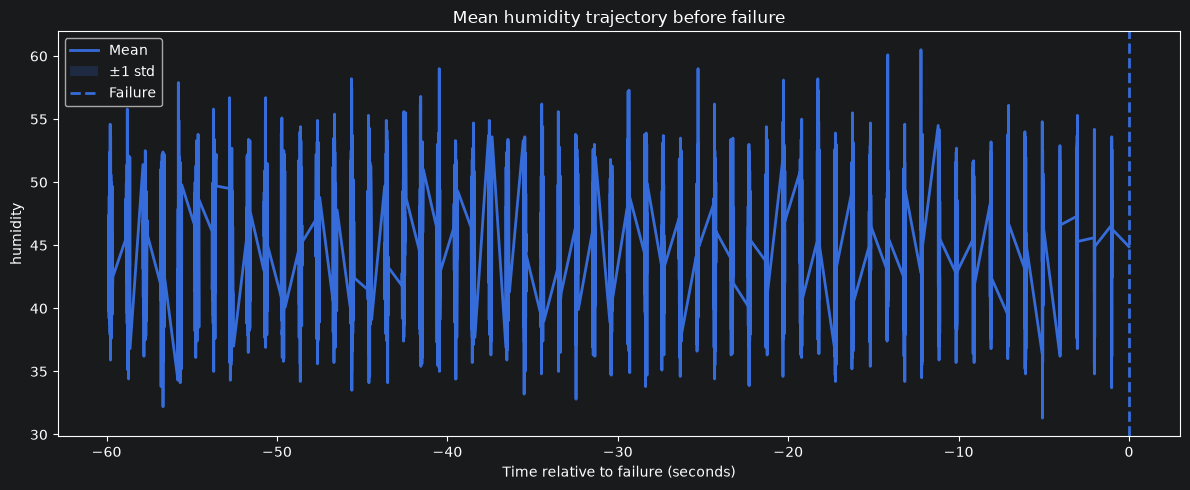

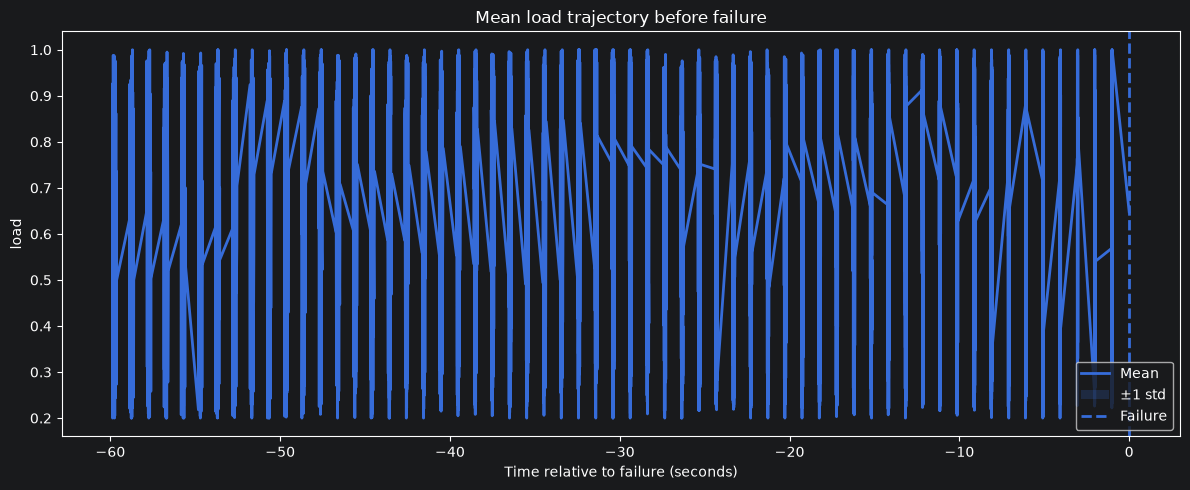

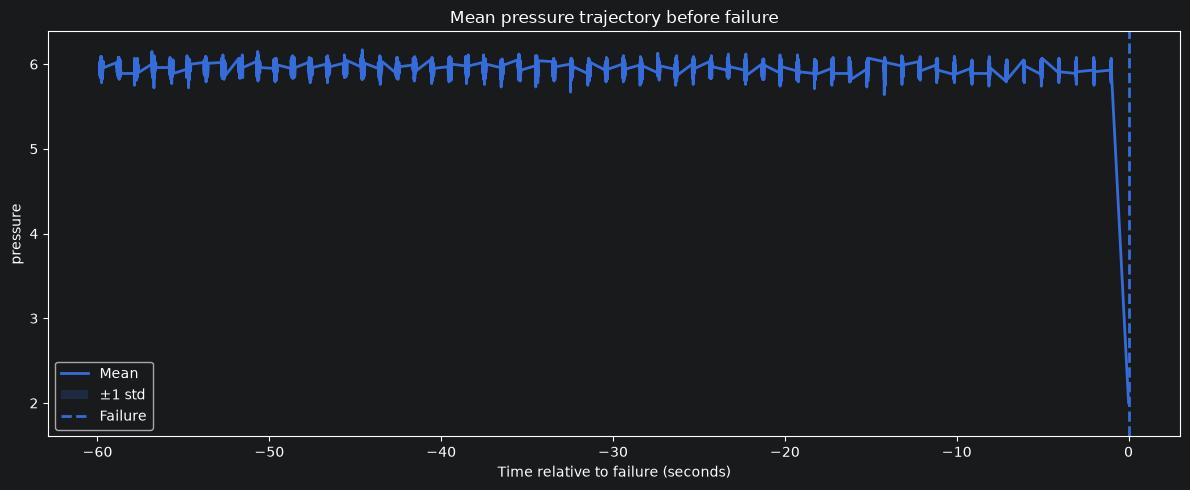

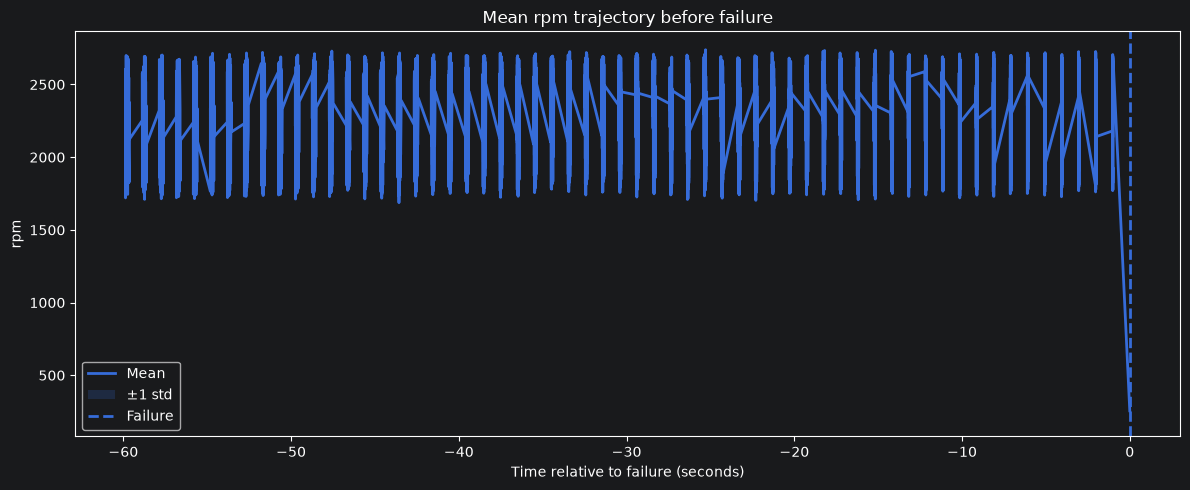

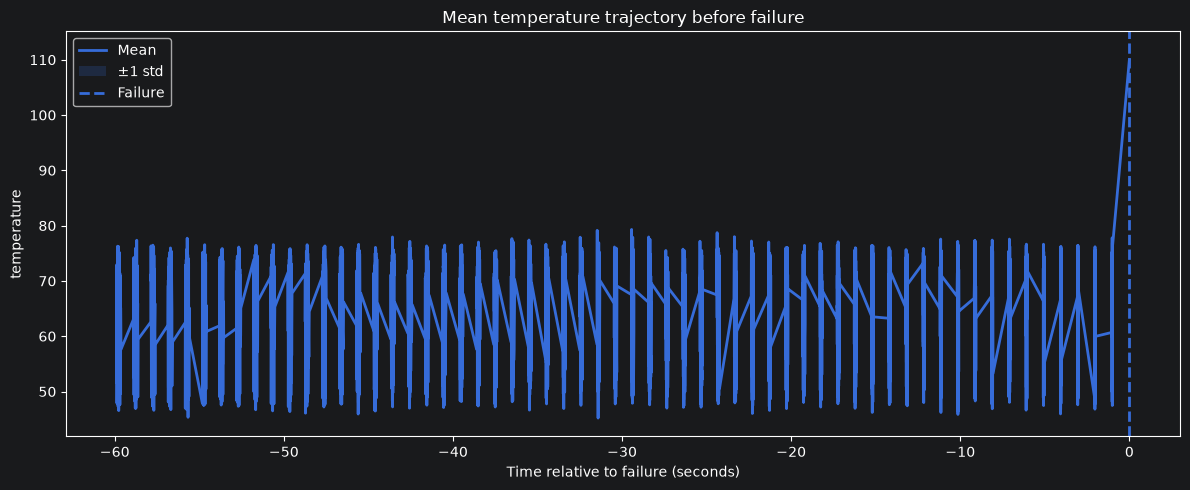

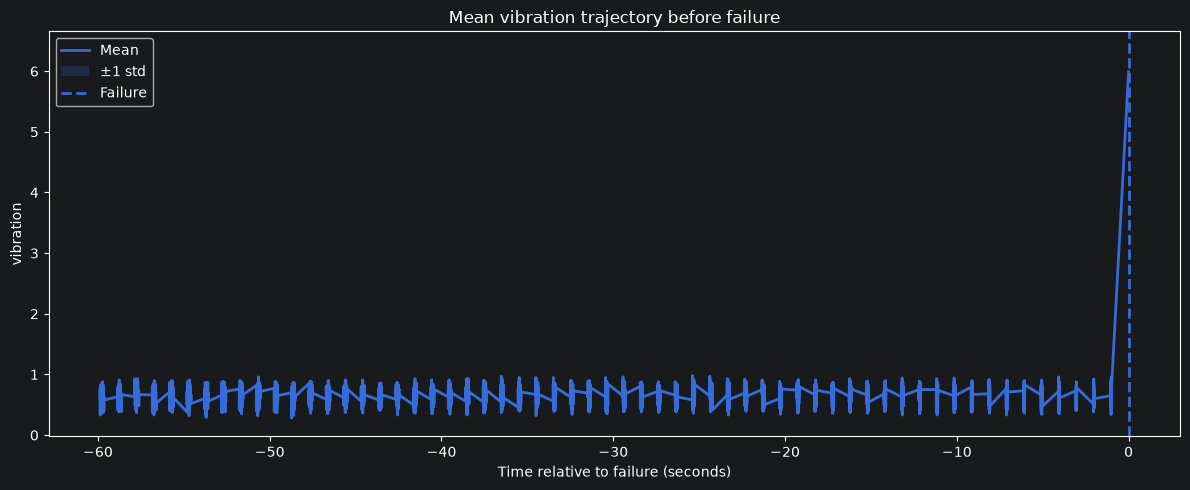

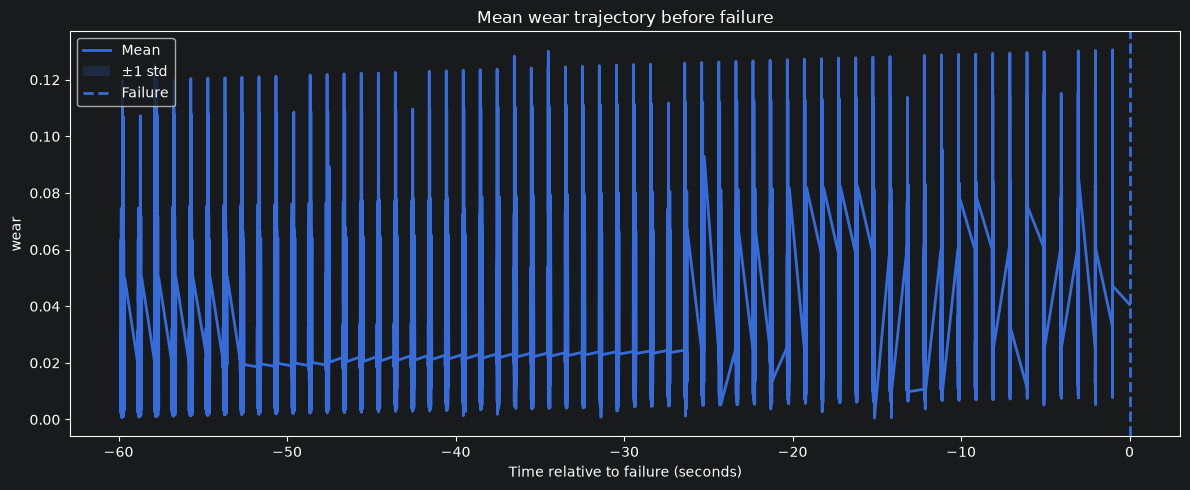

In [160]:
for feature in features:
    grouped = (
        failure_windows
        .groupby("relative_time")[feature]
        .agg(["mean", "std"])
        .sort_index()
    )

    plt.figure(figsize=(12, 5))

    plt.plot(
        grouped.index,
        grouped["mean"],
        linewidth=2,
        label="Mean",
    )

    plt.fill_between(
        grouped.index,
        grouped["mean"] - grouped["std"],
        grouped["mean"] + grouped["std"],
        alpha=0.2,
        label="±1 std",
    )

    plt.axvline(
        0,
        linestyle="--",
        linewidth=2,
        label="Failure",
    )

    plt.xlabel("Time relative to failure (seconds)")
    plt.ylabel(feature)
    plt.title(f"Mean {feature} trajectory before failure")
    plt.legend()
    plt.tight_layout()
    plt.show()

doesnt look like much. might need to take a second look at the simulation process

# ML

## Feature engineering

In [20]:
df = add_feature_failure_target(df, 60)

## Train test split

In [21]:
data = df.copy()

In [22]:
data["time"] = pd.to_datetime(data["time"])
data.sort_values(["time", "device_id"])

,time,device_id,current,failure,humidity,load,pressure,rpm,temperature,vibration,wear,failure_next
0,2026-08-15 12:40:02.862800+00:00,motor_000,14.58,0,43.7,0.542,6.01,2146.0,59.64,0.55,0.0001,0
16735,2026-08-15 12:40:02.870936+00:00,motor_002,15.31,0,42.6,0.562,6.12,2157.0,60.28,0.63,0.0001,0
24885,2026-08-15 12:40:02.872278+00:00,motor_003,14.29,0,51.3,0.529,5.94,2149.0,57.88,0.56,0.0001,0
8439,2026-08-15 12:40:02.965338+00:00,motor_001,15.49,0,46.7,0.569,5.98,2146.0,59.92,0.64,0.0001,0
8440,2026-08-15 12:40:04.188076+00:00,motor_001,15.36,0,47.3,0.572,5.94,2214.0,59.01,0.56,0.0003,0
...,...,...,...,...,...,...,...,...,...,...,...,...
8437,2026-08-15 15:02:28.991506+00:00,motor_000,14.33,0,49.8,0.467,5.97,2094.0,57.79,0.57,0.0392,0
32943,2026-08-15 15:02:28.991645+00:00,motor_003,17.01,0,45.6,0.660,5.95,2283.0,63.29,0.81,0.0351,0
24884,2026-08-15 15:02:28.991677+00:00,motor_002,10.99,0,42.7,0.343,5.95,1886.0,53.26,0.46,0.0186,0
16734,2026-08-15 15:02:29.992573+00:00,motor_001,20.94,0,49.8,0.898,5.96,2559.0,71.98,0.75,0.0032,0


In [23]:
test_size = 0.2
train = []
test = []

for _, device_data in data.groupby("device_id"):
    split_idx = int(len(device_data) * (1 - test_size))
    train.append(device_data.iloc[:split_idx])
    test.append(device_data.iloc[split_idx:])

train = pd.concat(train).sort_values(by=["device_id", "time"])
test = pd.concat(test).sort_values(by=["device_id", "time"])

In [24]:
train.shape

(26354, 12)

In [25]:
test.shape

(6590, 12)

In [26]:
y_train = train["failure_next"]
X_train = train.drop(columns=["time", "device_id", "failure", "failure_next"])

y_test = test["failure_next"]
X_test = test.drop(columns=["time", "device_id", "failure", "failure_next"])

## Train classifier

In [27]:
features = df.columns.drop(["device_id", "time", "failure", "failure_next"])

In [28]:
import mlflow

mlflow.set_tracking_uri("http://localhost:5000")

In [29]:
cl = train_model(X_train, y_train, features)

0:	total: 8.85ms	remaining: 4.42s
1:	total: 18ms	remaining: 4.48s
2:	total: 28.5ms	remaining: 4.72s
3:	total: 37.9ms	remaining: 4.7s
4:	total: 46.8ms	remaining: 4.63s
5:	total: 55.2ms	remaining: 4.55s
6:	total: 64.6ms	remaining: 4.55s
7:	total: 72.8ms	remaining: 4.48s
8:	total: 82.9ms	remaining: 4.52s
9:	total: 94.9ms	remaining: 4.65s
10:	total: 104ms	remaining: 4.62s
11:	total: 112ms	remaining: 4.56s
12:	total: 124ms	remaining: 4.63s
13:	total: 135ms	remaining: 4.67s
14:	total: 143ms	remaining: 4.62s
15:	total: 152ms	remaining: 4.59s
16:	total: 160ms	remaining: 4.54s
17:	total: 167ms	remaining: 4.47s
18:	total: 174ms	remaining: 4.41s
19:	total: 182ms	remaining: 4.36s
20:	total: 188ms	remaining: 4.3s
21:	total: 196ms	remaining: 4.26s
22:	total: 203ms	remaining: 4.21s
23:	total: 215ms	remaining: 4.26s
24:	total: 226ms	remaining: 4.3s
25:	total: 234ms	remaining: 4.27s
26:	total: 246ms	remaining: 4.3s
27:	total: 253ms	remaining: 4.27s
28:	total: 261ms	remaining: 4.24s
29:	total: 269ms	rem

In [30]:
y_pred = cl.predict(X_test)
y_prob = cl.predict_proba(X_test)


## Metrics

In [31]:
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)


In [32]:
metrics = {
    "roc_auc": roc_auc_score(y_test, y_pred),
    "average_precision": average_precision_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
}

for name, value in metrics.items():
    print(f"{name}: {value}")

roc_auc: 0.5553648612830642
average_precision: 0.2566579775515772
f1: 0.21540388227927365
precision: 0.63003663003663
recall: 0.1299093655589124


In [33]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.82      0.98      0.89      5266
           1       0.63      0.13      0.22      1324

    accuracy                           0.81      6590
   macro avg       0.72      0.56      0.55      6590
weighted avg       0.78      0.81      0.76      6590



## Confusion matrix

In [34]:
cm = confusion_matrix(y_test, y_pred)

In [36]:
cm

array([[5165,  101],
       [1152,  172]])

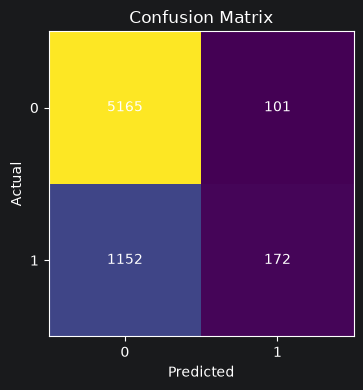

In [35]:
fig, ax = plt.subplots(figsize=(5, 4))

ax.imshow(cm)

ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

for i in range(2):
    for j in range(2):
        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
        )

plt.tight_layout()
plt.show()

## Feature importance

In [ ]:
importance = cl.get_feature_importance()
importance_data = dict(
    zip(features, importance, strict=False)
)

In [ ]:
importance_data.keys()

In [ ]:
names = [
    name
    for name in importance_data.keys()
]

values = [
    value
    for value in importance_data.values()
]

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(names, values)
ax.invert_yaxis()

ax.set_xlabel("Importance")
ax.set_title("CatBoost Feature Importance")

plt.tight_layout()
plt.show()

pretty sure humidity was generated as totally random and failure does not depend on it at all. it is the least important feature, yet the importance is not as low as one could expect